# 학습 학생 비율에 따른 분류 성능 변화 (박스플롯) — RQ2: 일반화

## 목적
학습에 사용하는 학생 비율(40%~80%)이 증가할 때 분류 성능(Cohen's Kappa)이 어떻게 달라지는지 비교합니다. "더 많은 학생의 데이터로 학습하면 다른 학생의 피드백도 잘 분류하는가?"라는 질문에 답합니다.

## 주요 용어
- **박스플롯(Box Plot)**: 데이터의 중앙값, 사분위수, 이상값을 한눈에 보여주는 차트. 상자의 가운데 선이 중앙값, 상자의 상하단이 25%/75% 지점
- **Cohen's Kappa(코헨의 카파)**: 두 평가자 간 일치도를 측정하는 지표로, 우연에 의한 일치를 보정함
- **학생 기반 분할**: 동일 학생의 피드백이 학습/테스트에 동시에 포함되지 않도록 학생 단위로 분할 (데이터 누출 방지)

## 실험 설계
- **전체 학생**: 55명 (총 2,080개 피드백)
- **학습 비율**: 40%, 50%, 60%, 70%, 80% (5단계)
- **ML**: 24개 모델(개별 9 + 앙상블 15) x 각 비율 x 3 seeds -> 박스플롯
- **BERT**: KLUE-BERT 단일 모델 x 각 비율 x 3 seeds -> 박스플롯
- **LLM**: GPT-4o 제로샷 — 학습 과정 없이 전체 데이터 Kappa -> 수평 참조선

## 시각화 구성
- A) 3패널 차트: ML + BERT 개별 박스플롯 + LLM 단일 표시
- B) 3패널 차트 + LLM 수평 참조선 오버레이

In [1]:
# ============================================================
# 라이브러리 및 한글 폰트 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

print('라이브러리 및 한글 폰트 설정 완료')

라이브러리 및 한글 폰트 설정 완료


In [ ]:
# ============================================================
# 데이터 파일 경로 설정
# ============================================================

# ML: 24모델 × 5비율 × 3 seeds (학생 기반 분할)
ML_PATH = '../2_ml/results/generalization/student_split/ss_all_results_student_split_parallel24.csv'

# BERT: 1모델 × 5비율 × 3 seeds (학생 기반 분할)
BERT_PATH = '../3_bert/results/generalization/bert_student_all.csv'

# LLM: GPT-4o 전체 예측 결과
LLM_PRED_PATH = '../4_llm/results/full_evaluation/llm_wide_predictions.csv'

print('파일 경로 설정 완료')

In [3]:
# ============================================================
# 데이터 로드 및 검증
# ============================================================

# --- ML 결과 ---
# 각 행 = 1개 모델 × 1개 비율/seed 조합의 결과
# Train_Pct: 학습에 사용한 학생 비율 (40, 50, 60, 70, 80)
# Model: 24개 모델명
# Test_Kappa: 테스트셋 Cohen's Kappa
ml_df = pd.read_csv(ML_PATH)
print(f'ML 데이터: {len(ml_df)}행')
print(f'  모델 수: {ml_df["Model"].nunique()}')
print(f'  비율: {sorted(ml_df["Train_Pct"].unique())}')
print(f'  Seeds: {sorted(ml_df["Seed"].unique())}')

# --- BERT 결과 ---
bert_df = pd.read_csv(BERT_PATH)
print(f'\nBERT 데이터: {len(bert_df)}행')
print(f'  비율: {sorted(bert_df["Train_Pct"].unique())}')
print(f'  Seeds: {sorted(bert_df["Seed"].unique())}')

# --- LLM 예측 ---
llm_pred = pd.read_csv(LLM_PRED_PATH)
llm_pred['y_true'] = llm_pred['y_true'].astype(int)
llm_pred['majority_pred'] = llm_pred['majority_pred'].astype(int)
print(f'\nLLM 예측 데이터: {len(llm_pred)}행')

# 비율별 데이터 포인트 수 확인
print('\n=== 비율별 데이터 포인트 수 ===')
for pct in sorted(ml_df['Train_Pct'].unique()):
    n_seeds_ml = ml_df[ml_df['Train_Pct'] == pct]['Seed'].nunique()
    n_ml = len(ml_df[ml_df['Train_Pct'] == pct])
    n_bert = len(bert_df[bert_df['Train_Pct'] == pct])
    print(f'  {pct}%: ML {n_ml}개({n_seeds_ml} seeds × 24모델), BERT {n_bert}개')

ML 데이터: 357행
  모델 수: 24
  비율: [40, 50, 60, 70, 80]
  Seeds: [42, 123, 456]

BERT 데이터: 15행
  비율: [40, 50, 60, 70, 80]
  Seeds: [42, 123, 456]

LLM 예측 데이터: 2080행

=== 비율별 데이터 포인트 수 ===
  40%: ML 69개(3 seeds × 24모델), BERT 3개
  50%: ML 72개(3 seeds × 24모델), BERT 3개
  60%: ML 72개(3 seeds × 24모델), BERT 3개
  70%: ML 72개(3 seeds × 24모델), BERT 3개
  80%: ML 72개(3 seeds × 24모델), BERT 3개


In [4]:
# ============================================================
# LLM 전체 데이터 Kappa 계산 (수평 참조선용)
# - LLM은 제로샷이므로 학생 비율과 무관
# - 전체 예측 결과에서 단일 Kappa 산출
# ============================================================

llm_overall_kappa = cohen_kappa_score(llm_pred['y_true'], llm_pred['majority_pred'])
print(f'LLM 전체 Kappa: {llm_overall_kappa:.4f}')
print(f'  (GPT-4o 제로샷, {len(llm_pred)}개 샘플 기반)')

LLM 전체 Kappa: 0.6249
  (GPT-4o 제로샷, 2080개 샘플 기반)


In [5]:
# ============================================================
# 공통 시각화 설정
# ============================================================

# 색상 팔레트 (프로젝트 공통)
PALETTE = {
    'ML':   '#4A90D9',   # 파란색
    'BERT': '#E8834A',   # 주황색
    'LLM':  '#67B279',   # 초록색
}

# 학습 비율 범위
TRAIN_PCTS = sorted(ml_df['Train_Pct'].unique())  # [40, 50, 60, 70, 80]

def add_kappa_guidelines(ax, show_labels=True):
    """Kappa 해석 기준선 추가 (Landis & Koch, 1977)."""
    for y, label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
        ax.axhline(y=y, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
        if show_labels:
            ax.annotate(
                label, xy=(1.0, y),
                xycoords=('axes fraction', 'data'),
                xytext=(6, 0), textcoords='offset points',
                fontsize=7, color='gray', alpha=0.7,
                va='center', ha='left', annotation_clip=False,
            )

def add_llm_reference(ax, kappa, show_label=True):
    """LLM 수평 참조선 추가."""
    ax.axhline(y=kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.8, linewidth=1.5, zorder=5)
    if show_label:
        ax.annotate(
            f'LLM : {kappa:.3f}',
            xy=(1.0, kappa),
            xycoords=('axes fraction', 'data'),
            xytext=(-8, 10), textcoords='offset points',
            fontsize=9, fontweight='bold', color=PALETTE['LLM'],
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=PALETTE['LLM'], alpha=0.9),
            annotation_clip=False,
        )

print('공통 시각화 설정 완료')

공통 시각화 설정 완료


In [6]:
# ============================================================
# long-format 데이터 구성
# ============================================================

records = []
for pct in TRAIN_PCTS:
    # ML: 24개 모델 × 3 seeds
    ml_sub = ml_df[ml_df['Train_Pct'] == pct]
    for _, row in ml_sub.iterrows():
        records.append({'Train_Pct': pct, 'Approach': 'ML', 'Kappa': row['Test_Kappa']})
    # BERT: 1모델 × 3 seeds
    bert_sub = bert_df[bert_df['Train_Pct'] == pct]
    for _, row in bert_sub.iterrows():
        records.append({'Train_Pct': pct, 'Approach': 'BERT', 'Kappa': row['Test_Kappa']})

df_long = pd.DataFrame(records)
df_long['Approach'] = pd.Categorical(df_long['Approach'], categories=['ML', 'BERT'], ordered=True)

print(f'통합 데이터: {len(df_long)}행')
print(df_long.groupby(['Train_Pct', 'Approach']).size().unstack(fill_value=0))

통합 데이터: 372행
Approach   ML  BERT
Train_Pct          
40         69     3
50         72     3
60         72     3
70         72     3
80         72     3


## A) ML | BERT | LLM 3패널 박스플롯

- 왼쪽: ML (24모델 × 3 seeds) 박스플롯 + 평균 추세선
- 가운데: BERT (KLUE-BERT × 3 seeds) 박스플롯 + 평균 추세선
- 오른쪽: LLM (GPT-4o) 전체 Kappa 단일 표시
- 평균값은 항상 최상위 레이어에 표시

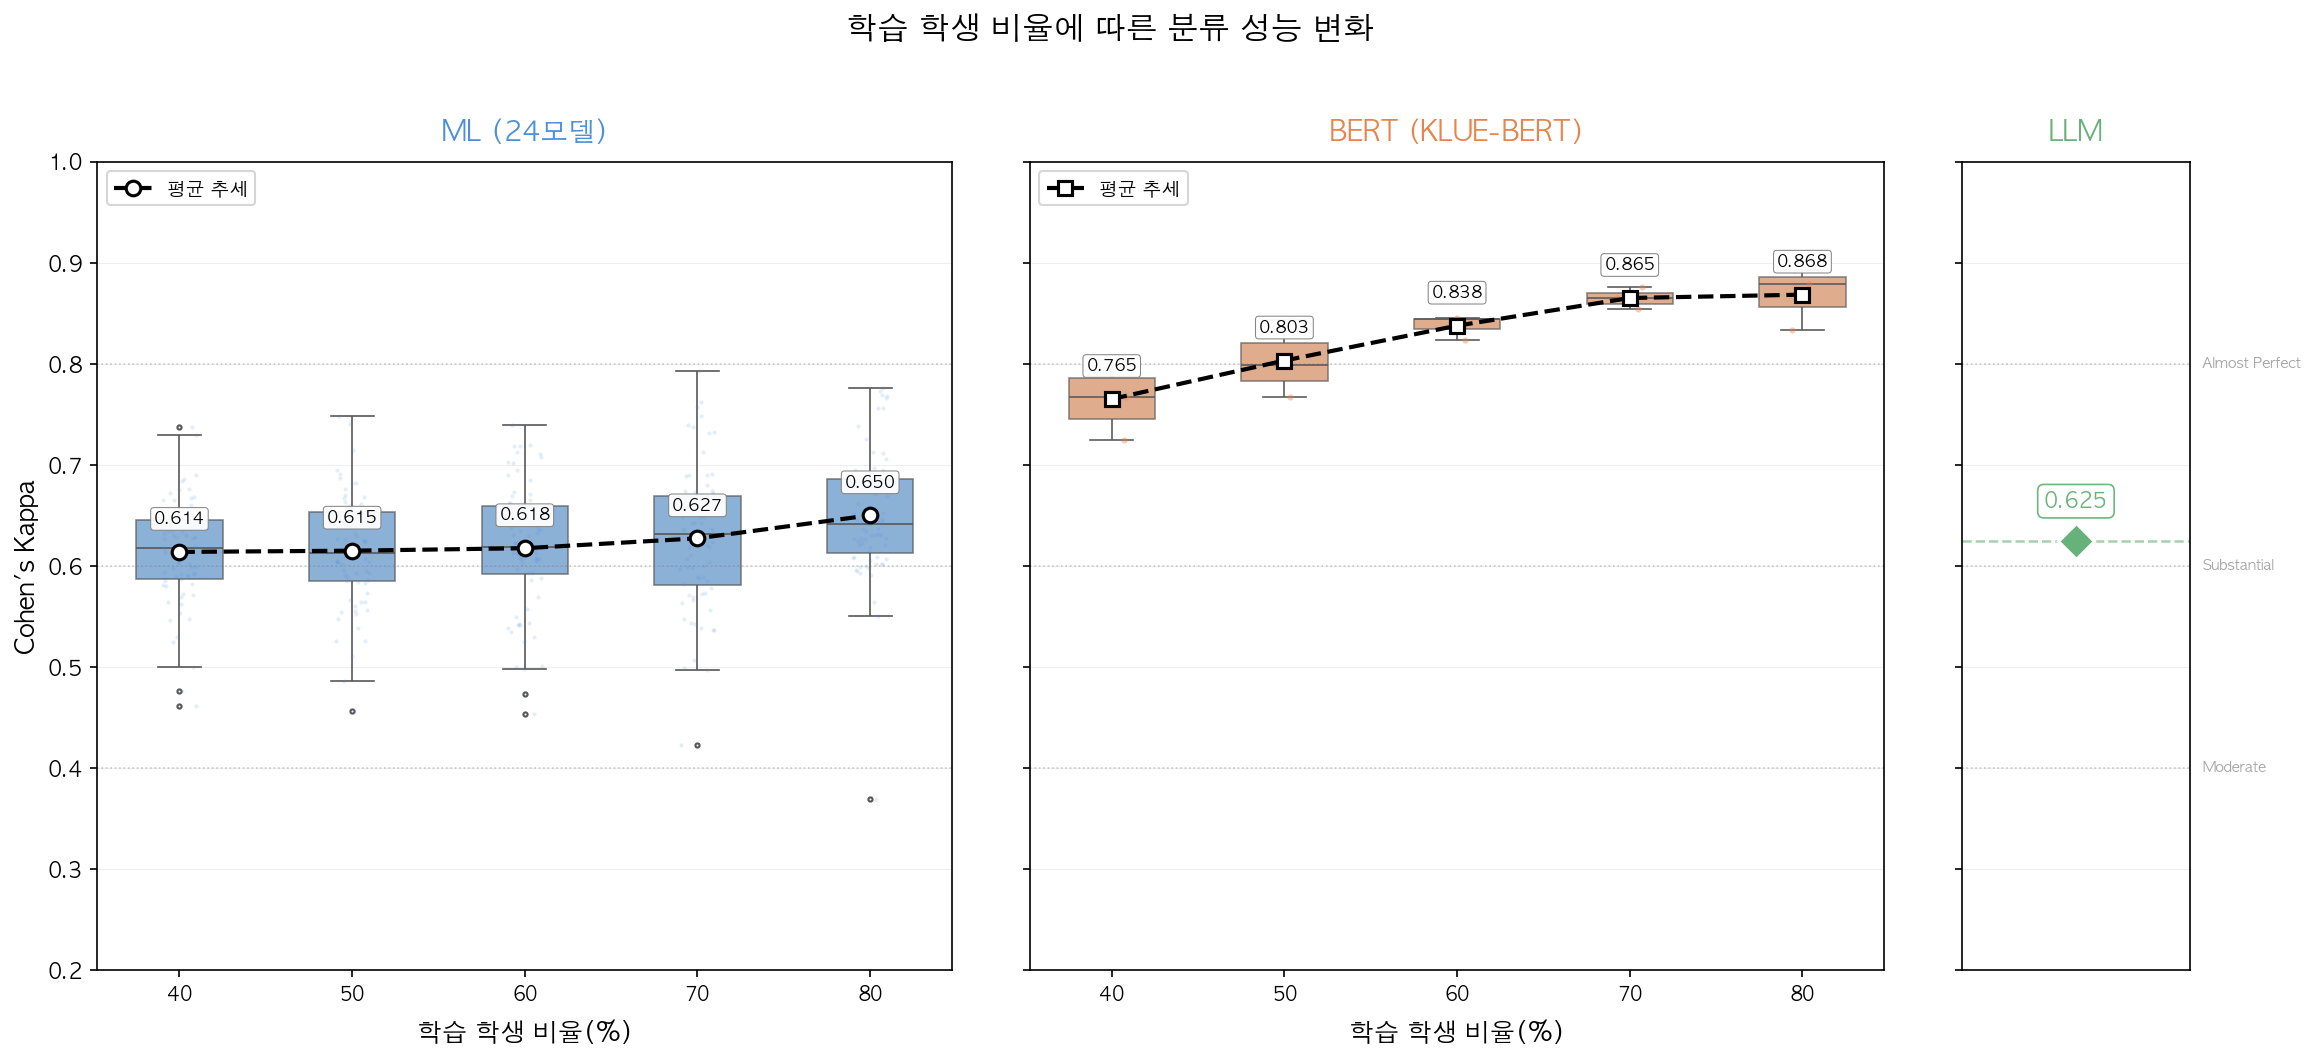


=== 비율별 Kappa 평균 ===
           mean_ML  mean_BERT  std_ML  std_BERT     LLM
Train_Pct                                              
40          0.6139     0.7652  0.0521    0.0397  0.6249
50          0.6152     0.8033  0.0551    0.0379  0.6249
60          0.6176     0.8378  0.0630    0.0120  0.6249
70          0.6274     0.8652  0.0698    0.0109  0.6249
80          0.6502     0.8685  0.0627    0.0313  0.6249


In [7]:
# ============================================================
# A) ML | BERT | LLM  3패널 박스플롯
# ============================================================

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 0.8], wspace=0.12)
ax_ml   = fig.add_subplot(gs[0])
ax_bert = fig.add_subplot(gs[1], sharey=ax_ml)
ax_llm  = fig.add_subplot(gs[2], sharey=ax_ml)

x_pos = np.arange(len(TRAIN_PCTS))

# ---- ML 패널 ----
ml_data = df_long[df_long['Approach'] == 'ML']

sns.boxplot(
    data=ml_data, x='Train_Pct', y='Kappa',
    color=PALETTE['ML'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_ml,
)
sns.stripplot(
    data=ml_data, x='Train_Pct', y='Kappa',
    color=PALETTE['ML'], size=2, alpha=0.15, jitter=True, ax=ax_ml,
)

ml_means = ml_data.groupby('Train_Pct')['Kappa'].mean().sort_index()
ax_ml.plot(x_pos, ml_means.values, 'k--o', markersize=7, linewidth=2,
           markerfacecolor='white', markeredgecolor='black',
           markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, ml_means.values):
    ax_ml.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

ax_ml.set_title('ML (24모델)', fontsize=13, fontweight='bold',
                pad=10, color=PALETTE['ML'])
ax_ml.set_xlabel('학습 학생 비율(%)', fontsize=12, fontweight='bold', labelpad=8)
ax_ml.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax_ml.set_xticklabels([str(pct) for pct in TRAIN_PCTS], fontsize=9)
ax_ml.legend(fontsize=9, loc='upper left')

# ---- BERT 패널 ----
bert_data = df_long[df_long['Approach'] == 'BERT']

sns.boxplot(
    data=bert_data, x='Train_Pct', y='Kappa',
    color=PALETTE['BERT'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_bert,
)
sns.stripplot(
    data=bert_data, x='Train_Pct', y='Kappa',
    color=PALETTE['BERT'], size=3, alpha=0.4, jitter=True, ax=ax_bert,
)

bert_means = bert_data.groupby('Train_Pct')['Kappa'].mean().sort_index()
ax_bert.plot(x_pos, bert_means.values, 'k--s', markersize=7, linewidth=2,
             markerfacecolor='white', markeredgecolor='black',
             markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, bert_means.values):
    ax_bert.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

ax_bert.set_title('BERT (KLUE-BERT)', fontsize=13, fontweight='bold',
                  pad=10, color=PALETTE['BERT'])
ax_bert.set_xlabel('학습 학생 비율(%)', fontsize=12, fontweight='bold', labelpad=8)
ax_bert.set_ylabel('')
plt.setp(ax_bert.get_yticklabels(), visible=False)
ax_bert.set_xticklabels([str(pct) for pct in TRAIN_PCTS], fontsize=9)
ax_bert.legend(fontsize=9, loc='upper left')

# ---- LLM 패널 (단일 값) ----
ax_llm.axhline(y=llm_overall_kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.6, linewidth=1.2)
ax_llm.plot(0, llm_overall_kappa, 'D', color=PALETTE['LLM'],
            markersize=12, markeredgecolor='white', markeredgewidth=1.5, zorder=20)
ax_llm.annotate(
    f'{llm_overall_kappa:.3f}', xy=(0, llm_overall_kappa), xytext=(0, 14),
    textcoords='offset points', fontsize=10, fontweight='bold',
    ha='center', va='bottom', color=PALETTE['LLM'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=PALETTE['LLM'], alpha=0.95, linewidth=0.8),
    zorder=25,
)

ax_llm.set_title('LLM', fontsize=13, fontweight='bold',
                 pad=10, color=PALETTE['LLM'])
ax_llm.set_xlabel(' ', fontsize=10, labelpad=8)
ax_llm.set_ylabel('')
plt.setp(ax_llm.get_yticklabels(), visible=False)
ax_llm.set_xlim(-0.8, 0.8)
ax_llm.set_xticks([])

# ---- 공통 설정 ----
for ax in [ax_ml, ax_bert, ax_llm]:
    ax.set_ylim(0.2, 1.0)
    for y_val in [0.4, 0.6, 0.8]:
        ax.axhline(y=y_val, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

# 기준선 라벨 (LLM 패널 오른쪽에 1회만)
for y_val, y_label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
    ax_llm.annotate(
        y_label, xy=(1.0, y_val),
        xycoords=('axes fraction', 'data'),
        xytext=(6, 0), textcoords='offset points',
        fontsize=7, color='gray', alpha=0.7,
        va='center', ha='left', annotation_clip=False,
    )

fig.suptitle('학습 학생 비율에 따른 분류 성능 변화',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('student_ratio_boxplot_A_combined.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 요약 통계
print('\n=== 비율별 Kappa 평균 ===')
summary = df_long.pivot_table(values='Kappa', index='Train_Pct', columns='Approach', aggfunc=['mean', 'std'])
summary.columns = [f'{stat}_{app}' for stat, app in summary.columns]
summary['LLM'] = llm_overall_kappa
print(summary.round(4).to_string())

**결과 해석:**

3패널 박스플롯(A)은 학습 학생 비율 증가에 따른 성능 변화를 보여줍니다.

- **ML 패널(왼쪽)**: 40%(~0.61) -> 80%(~0.65)로 소폭 상승. 학생 수 증가에 따른 향상폭이 크지 않으며, 모델 간 분산(박스 크기)이 비율에 관계없이 넓음 → ML은 학생 수보다 모델 선택의 영향이 더 큼
- **BERT 패널(가운데)**: 40%(~0.76) -> 80%(~0.84)로 더 큰 향상. 3개 seed의 점이 표시되어 있으며, 비율 증가에 따라 안정적으로 성능이 향상
- **LLM 패널(오른쪽)**: 전체 데이터 Kappa(0.625) 단일 다이아몬드 표시. 학습 과정이 없으므로 학생 비율과 무관
- **핵심 발견**: BERT는 40%의 학생 데이터(22명)만으로도 LLM의 전체 데이터 성능(0.625)을 상회하며, 학생 수 증가에 따른 성능 향상이 ML보다 효율적

## B) ML | BERT | LLM 분리 차트 (LLM 수평 참조선 포함)

- ML, BERT 패널 안에 LLM Kappa 수평 참조선을 겹쳐 표시
- 학습 모델과 제로샷 모델의 성능 차이를 각 패널에서 직접 비교 가능

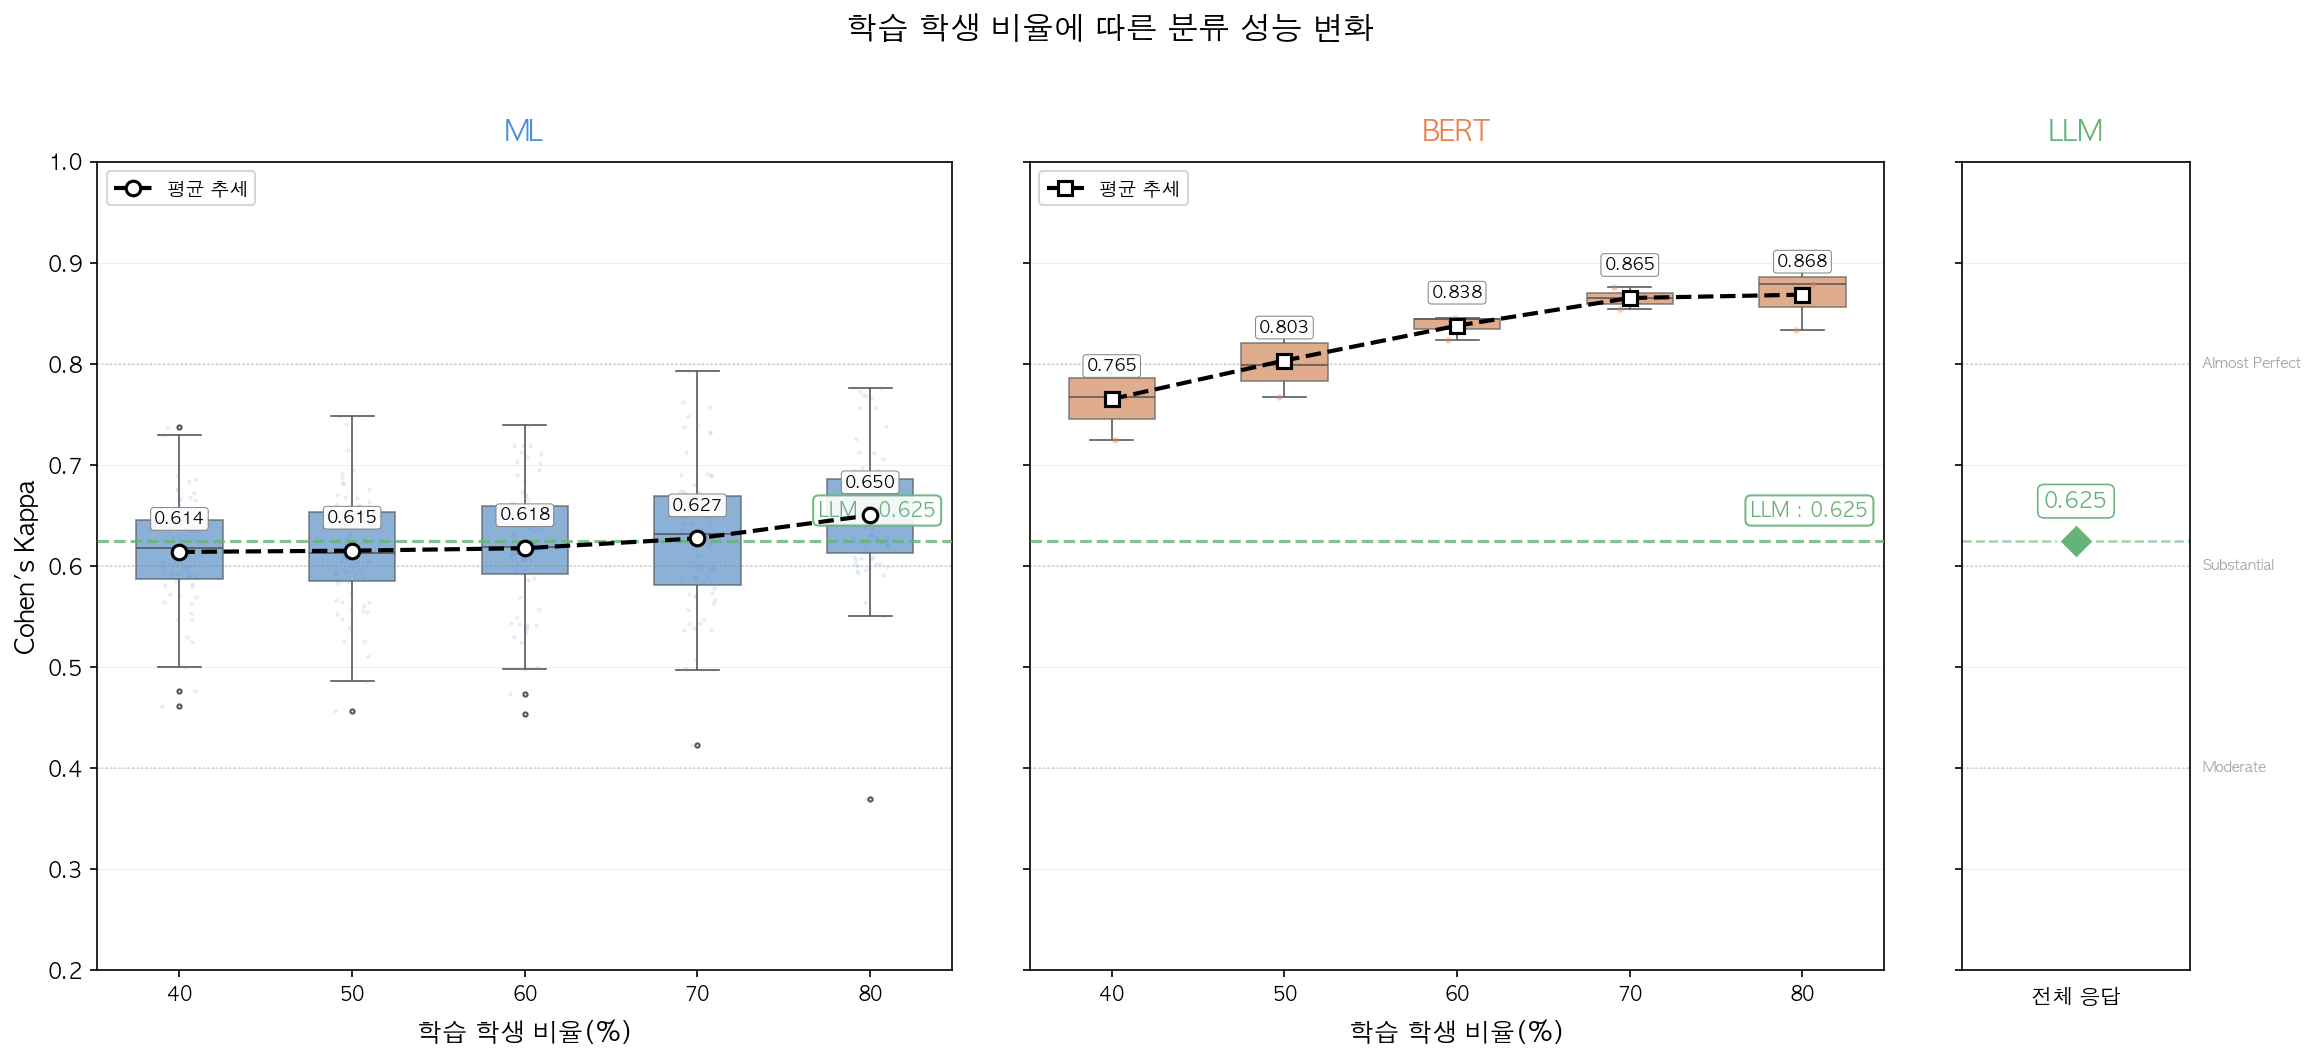

ML 평균 추세:  0.614 → 0.615 → 0.618 → 0.627 → 0.650
BERT 평균 추세: 0.765 → 0.803 → 0.838 → 0.865 → 0.868
LLM 기준선:     0.625

ML 향상폭:   40%(0.614) → 80%(0.650), Δ=0.036
BERT 향상폭: 40%(0.765) → 80%(0.868), Δ=0.103


In [8]:
# ============================================================
# B) ML | BERT | LLM 분리 차트 (LLM 수평 참조선 포함)
# ============================================================

fig = plt.figure(figsize=(18, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[3, 3, 0.8], wspace=0.12)
ax_ml   = fig.add_subplot(gs[0])
ax_bert = fig.add_subplot(gs[1], sharey=ax_ml)
ax_llm  = fig.add_subplot(gs[2], sharey=ax_ml)

x_pos = np.arange(len(TRAIN_PCTS))

# ---- ML 패널 ----
ml_data = df_long[df_long['Approach'] == 'ML']

sns.boxplot(
    data=ml_data, x='Train_Pct', y='Kappa',
    color=PALETTE['ML'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_ml,
)
sns.stripplot(
    data=ml_data, x='Train_Pct', y='Kappa',
    color=PALETTE['ML'], size=2, alpha=0.15, jitter=True, ax=ax_ml,
)

ml_means = ml_data.groupby('Train_Pct')['Kappa'].mean().sort_index()
ax_ml.plot(x_pos, ml_means.values, 'k--o', markersize=7, linewidth=2,
           markerfacecolor='white', markeredgecolor='black',
           markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, ml_means.values):
    ax_ml.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

# LLM 수평 참조선
add_llm_reference(ax_ml, llm_overall_kappa)

ax_ml.set_title('ML', fontsize=13, fontweight='bold',
                pad=10, color=PALETTE['ML'])
ax_ml.set_xlabel('학습 학생 비율(%)', fontsize=12, fontweight='bold', labelpad=8)
ax_ml.set_ylabel("Cohen's Kappa", fontsize=12, fontweight='bold')
ax_ml.set_xticklabels([str(pct) for pct in TRAIN_PCTS], fontsize=9)
ax_ml.legend(fontsize=9, loc='upper left')

# ---- BERT 패널 ----
bert_data = df_long[df_long['Approach'] == 'BERT']

sns.boxplot(
    data=bert_data, x='Train_Pct', y='Kappa',
    color=PALETTE['BERT'], width=0.5, fliersize=2, linewidth=0.8,
    boxprops=dict(alpha=0.7), ax=ax_bert,
)
sns.stripplot(
    data=bert_data, x='Train_Pct', y='Kappa',
    color=PALETTE['BERT'], size=3, alpha=0.4, jitter=True, ax=ax_bert,
)

bert_means = bert_data.groupby('Train_Pct')['Kappa'].mean().sort_index()
ax_bert.plot(x_pos, bert_means.values, 'k--s', markersize=7, linewidth=2,
             markerfacecolor='white', markeredgecolor='black',
             markeredgewidth=1.5, zorder=20, label='평균 추세')

for xp, mv in zip(x_pos, bert_means.values):
    ax_bert.annotate(
        f'{mv:.3f}', xy=(xp, mv), xytext=(0, 12),
        textcoords='offset points', fontsize=8, fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='gray', alpha=0.95, linewidth=0.5),
        zorder=25,
    )

# LLM 수평 참조선
add_llm_reference(ax_bert, llm_overall_kappa)

ax_bert.set_title('BERT', fontsize=13, fontweight='bold',
                  pad=10, color=PALETTE['BERT'])
ax_bert.set_xlabel('학습 학생 비율(%)', fontsize=12, fontweight='bold', labelpad=8)
ax_bert.set_ylabel('')
plt.setp(ax_bert.get_yticklabels(), visible=False)
ax_bert.set_xticklabels([str(pct) for pct in TRAIN_PCTS], fontsize=9)
ax_bert.legend(fontsize=9, loc='upper left')

# ---- LLM 패널 (단일 값) ----
ax_llm.axhline(y=llm_overall_kappa, color=PALETTE['LLM'], linestyle='--',
               alpha=0.6, linewidth=1.2)
ax_llm.plot(0, llm_overall_kappa, 'D', color=PALETTE['LLM'],
            markersize=12, markeredgecolor='white', markeredgewidth=1.5, zorder=20)
ax_llm.annotate(
    f'{llm_overall_kappa:.3f}', xy=(0, llm_overall_kappa), xytext=(0, 14),
    textcoords='offset points', fontsize=10, fontweight='bold',
    ha='center', va='bottom', color=PALETTE['LLM'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
              edgecolor=PALETTE['LLM'], alpha=0.95, linewidth=0.8),
    zorder=25,
)

ax_llm.set_title('LLM', fontsize=13, fontweight='bold',
                 pad=10, color=PALETTE['LLM'])
ax_llm.set_xlabel('전체 응답', fontsize=10, labelpad=8)
ax_llm.set_ylabel('')
plt.setp(ax_llm.get_yticklabels(), visible=False)
ax_llm.set_xlim(-0.8, 0.8)
ax_llm.set_xticks([])

# ---- 공통 설정 ----
for ax in [ax_ml, ax_bert, ax_llm]:
    ax.set_ylim(0.2, 1.0)
    for y_val in [0.4, 0.6, 0.8]:
        ax.axhline(y=y_val, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)
    ax.grid(axis='y', alpha=0.2, linewidth=0.5)
    ax.set_axisbelow(True)

# 기준선 라벨
for y_val, y_label in [(0.4, 'Moderate'), (0.6, 'Substantial'), (0.8, 'Almost Perfect')]:
    ax_llm.annotate(
        y_label, xy=(1.0, y_val),
        xycoords=('axes fraction', 'data'),
        xytext=(6, 0), textcoords='offset points',
        fontsize=7, color='gray', alpha=0.7,
        va='center', ha='left', annotation_clip=False,
    )

fig.suptitle('학습 학생 비율에 따른 분류 성능 변화',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('student_ratio_boxplot_B_separate.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# --- 요약 ---
print(f'ML 평균 추세:  {" → ".join(f"{v:.3f}" for v in ml_means.values)}')
print(f'BERT 평균 추세: {" → ".join(f"{v:.3f}" for v in bert_means.values)}')
print(f'LLM 기준선:     {llm_overall_kappa:.3f}')
print(f'\nML 향상폭:   40%({ml_means.iloc[0]:.3f}) → 80%({ml_means.iloc[-1]:.3f}), Δ={ml_means.iloc[-1]-ml_means.iloc[0]:.3f}')
print(f'BERT 향상폭: 40%({bert_means.iloc[0]:.3f}) → 80%({bert_means.iloc[-1]:.3f}), Δ={bert_means.iloc[-1]-bert_means.iloc[0]:.3f}')

**결과 해석:**

차트 B는 ML/BERT 패널에 LLM Kappa 수평 참조선(녹색 점선, 0.625)을 오버레이하여 비교합니다.

- **ML-LLM 비교**: ML의 24개 모델 중 상위 모델들은 40% 비율부터 LLM을 초과하지만, 하위 모델들은 80%에서도 LLM에 미치지 못함 → ML은 모델 선택이 중요
- **BERT-LLM 비교**: BERT는 모든 비율에서 LLM을 크게 상회 → 소량의 학생 데이터로도 프롬프트 기반 LLM보다 우수
- **향상폭 비교**: ML의 40%->80% 향상폭(약 0.04)이 BERT(약 0.08)보다 작음 → BERT가 추가 데이터를 더 효과적으로 활용
- **실용적 시사점**: 교육 현장에서 피드백 자동 분류를 도입할 때, 약 40%(22명)의 학생 데이터만 수작업 라벨링해도 BERT 기반 시스템이 충분히 활용 가능